# TD5: Mesh Graph Networks for Flow Field Prediction

The goal here is to build a MeshGraphNet that predicts mean pressure and velocity fields (u, v, p) for flow past centered obstacles. We have 60 VTU simulations with different obstacle shapes (circles, ellipses, rectangles) and inlet velocities. I'll go through each question step by step, starting with data loading and preprocessing.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import pyvista as pv
import json
import os
from pathlib import Path
from scipy.spatial import cKDTree

pv.OFF_SCREEN = True  # no GUI

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}, device: {device}")

DATA_DIR = Path("dataset")
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)
print(f"Loaded metadata for {len(metadata)} simulations")

PyTorch 2.10.0+cu128, device: cuda
Loaded metadata for 60 simulations


# Q1. Data Preprocessing and Signed Distance Function

Let's start by loading a single mesh and seeing what's inside. The assignment says to use pyvista for reading VTU files.

In [2]:
# Load a sample mesh
mesh = pv.read(str(DATA_DIR / "flow_000.vtu"))
print(f"Number of points: {mesh.n_points}")
print(f"Number of cells: {mesh.n_cells}")
print(f"Point data arrays: {list(mesh.point_data.keys())}")
print(f"Bounds: {mesh.bounds}")
print(f"\nFirst few points:\n{mesh.points[:5]}")

# Extract boundary using pyvista
boundary = mesh.extract_feature_edges().points
print(f"\nBoundary points: {len(boundary)}")

Number of points: 950
Number of cells: 1750
Point data arrays: ['u', 'v', 'p']
Bounds: BoundsTuple(x_min = 0.0,
            x_max = 2.2,
            y_min = 0.0,
            y_max = 0.41,
            z_min = 0.0,
            z_max = 0.0)

First few points:
[[0.    0.    0.   ]
 [2.2   0.    0.   ]
 [2.2   0.41  0.   ]
 [0.    0.41  0.   ]
 [1.1   0.205 0.   ]]

Boundary points: 148


We have about 950 nodes and 1750 triangular cells per mesh. The domain is a 2.2 x 0.41 channel. The point data contains velocity components (u, v) and pressure (p). Let me visualize the mesh and fields for this first sample.

Extracted 1750 triangles


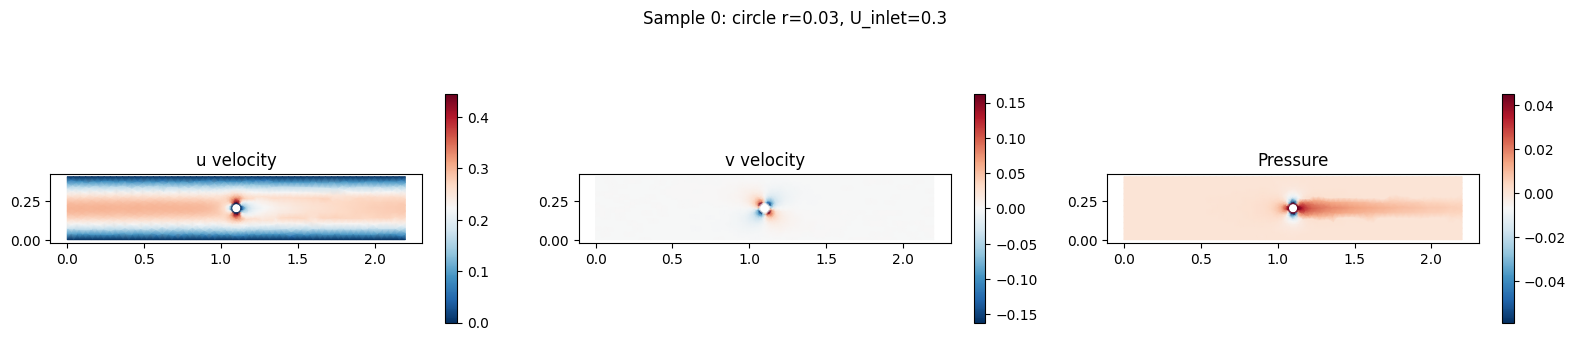

In [3]:
coords = mesh.points[:, :2]  # just x, y
x, y = coords[:, 0], coords[:, 1]

# Extract triangle connectivity from the unstructured grid
# For an UnstructuredGrid, cells are stored differently
cells_array = mesh.cells  # returns a CellArray
# Get just the triangle cells (type 5 in VTK)
triangles_list = []
offset = 0
cell_connectivity = mesh.cell_connectivity
cell_offsets = mesh.offset
for i in range(mesh.n_cells):
    start = cell_offsets[i]
    if i < mesh.n_cells - 1:
        end = cell_offsets[i + 1]
    else:
        end = len(cell_connectivity)
    cell_nodes = cell_connectivity[start:end]
    if len(cell_nodes) == 3:
        triangles_list.append(cell_nodes)

triangles = np.array(triangles_list)
print(f"Extracted {len(triangles)} triangles")
triang = mtri.Triangulation(x, y, triangles)

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

for ax, field, title in zip(axes, ['u', 'v', 'p'], ['u velocity', 'v velocity', 'Pressure']):
    vals = mesh.point_data[field]
    tc = ax.tripcolor(triang, vals, cmap='RdBu_r', shading='gouraud')
    plt.colorbar(tc, ax=ax, shrink=0.8)
    ax.set_title(title)
    ax.set_aspect('equal')

plt.suptitle(f"Sample 0: circle r=0.03, U_inlet=0.3", y=1.02)
plt.tight_layout()
plt.show()

The flow fields look reasonable. We can see the u-velocity is highest in the center of the channel, the v-velocity shows deflection around the obstacle, and the pressure field has a stagnation point upstream. Now let me classify nodes and compute the signed distance function.

## Node Classification and SDF

The assignment says to classify nodes as: boundary = 0, interior = 1, inlet = 2, outlet = 3. The boundaries include walls (top/bottom) and the obstacle surface. The inlet is the left edge (x=0), the outlet is the right edge (x=2.2), and everything else is interior.

For the SDF, we compute the distance from each node to the nearest boundary point using a cKDTree, then make it negative for nodes that are "inside" the obstacle (though in our case all mesh nodes are in the fluid domain, so the SDF is just the unsigned distance to the nearest boundary).

In [4]:
def classify_nodes(mesh):
    """Classify each node: boundary=0, interior=1, inlet=2, outlet=3."""
    coords = mesh.points[:, :2]
    x, y = coords[:, 0], coords[:, 1]
    L, H = x.max(), y.max()
    tol = 1e-3
    
    node_type = np.ones(len(coords), dtype=np.int64)  # default: interior
    
    # Inlet: left edge (x ~ 0)
    node_type[x < tol] = 2
    # Outlet: right edge (x ~ L)
    node_type[x > L - tol] = 3
    # Boundary: top wall, bottom wall, and obstacle surface
    # Top/bottom walls
    node_type[y < tol] = 0
    node_type[y > H - tol] = 0
    
    # Obstacle boundary: points that are on the feature edges but NOT on the channel walls
    boundary_mesh = mesh.extract_feature_edges()
    boundary_pts = boundary_mesh.points[:, :2]
    
    # Find mesh nodes that lie on the boundary edges (within tolerance)
    tree = cKDTree(boundary_pts)
    dists, _ = tree.query(coords)
    on_boundary = dists < tol * 5
    
    # Among those on the boundary, identify obstacle nodes
    # Obstacle nodes are boundary nodes NOT on the channel walls or inlet/outlet
    obstacle_mask = on_boundary & (x > tol) & (x < L - tol) & (y > tol) & (y < H - tol)
    node_type[obstacle_mask] = 0
    
    return node_type

def compute_sdf(mesh):
    """Compute signed distance function: distance to nearest boundary."""
    coords = mesh.points[:, :2]
    boundary_pts = mesh.extract_feature_edges().points[:, :2]
    
    tree = cKDTree(boundary_pts)
    sdf, _ = tree.query(coords)
    return sdf

# Test on sample 0
node_type = classify_nodes(mesh)
sdf = compute_sdf(mesh)

for t, name in [(0, "boundary"), (1, "interior"), (2, "inlet"), (3, "outlet")]:
    print(f"  {name}: {(node_type == t).sum()} nodes")

  boundary: 128 nodes
  interior: 802 nodes
  inlet: 10 nodes
  outlet: 10 nodes


The classification picks up 128 boundary nodes (walls + obstacle), 802 interior nodes, and about 10 each for inlet and outlet. Let me visualize both the SDF field and the node type map.

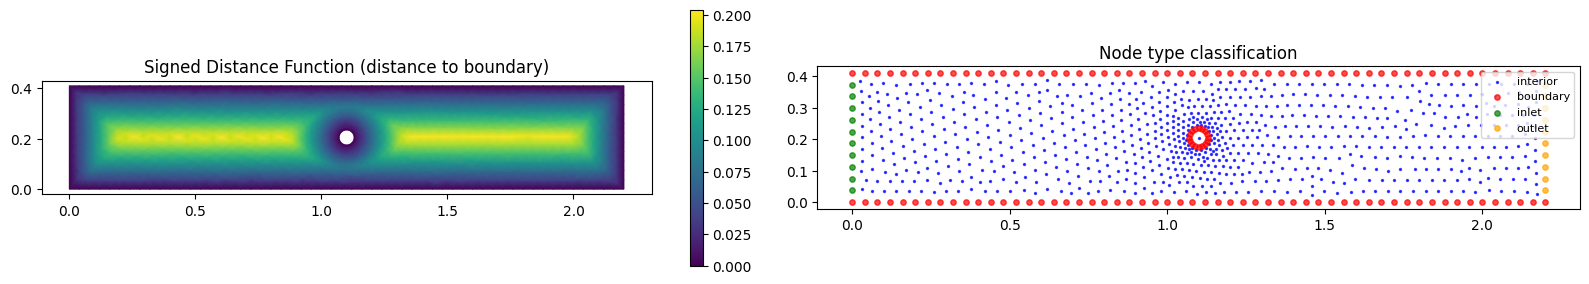

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 3.5))

# SDF visualization
tc = axes[0].tripcolor(triang, sdf, cmap='viridis', shading='gouraud')
plt.colorbar(tc, ax=axes[0], shrink=0.8)
axes[0].set_title('Signed Distance Function (distance to boundary)')
axes[0].set_aspect('equal')

# Node type visualization
colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange'}
labels = {0: 'boundary', 1: 'interior', 2: 'inlet', 3: 'outlet'}
for t in [1, 0, 2, 3]:  # interior first (background)
    mask = node_type == t
    s = 2 if t == 1 else 15
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=colors[t], s=s, label=labels[t], alpha=0.7)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_title('Node type classification')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

The SDF plot shows that values are highest in the center of the channel (farthest from all boundaries) and go to zero at walls, inlet, outlet, and the obstacle surface. The node type plot correctly identifies the four categories: red boundary nodes form the walls and the circular obstacle, green and orange nodes mark the inlet (left) and outlet (right), and blue fills the interior.

Now let me process all 60 meshes and build the full preprocessed dataset.

In [6]:
def process_all_meshes(data_dir, metadata):
    """Process all VTU files: extract coords, connectivity, fields, node types, SDF."""
    processed = []
    for i, meta in enumerate(metadata):
        mesh = pv.read(str(data_dir / meta["file"]))
        coords = mesh.points[:, :2].astype(np.float32)
        node_type = classify_nodes(mesh)
        sdf = compute_sdf(mesh).astype(np.float32)
        
        # Extract triangle connectivity
        cell_conn = mesh.cell_connectivity
        cell_off = mesh.offset
        triangles = []
        for j in range(mesh.n_cells):
            s = cell_off[j]
            e = cell_off[j + 1] if j < mesh.n_cells - 1 else len(cell_conn)
            cn = cell_conn[s:e]
            if len(cn) == 3:
                triangles.append(cn)
        triangles = np.array(triangles)
        
        # Target fields
        u = mesh.point_data['u'].astype(np.float32)
        v = mesh.point_data['v'].astype(np.float32)
        p = mesh.point_data['p'].astype(np.float32)
        
        processed.append({
            'coords': coords, 'triangles': triangles,
            'node_type': node_type, 'sdf': sdf,
            'u': u, 'v': v, 'p': p,
            'U_inlet': meta['U_inlet'], 'meta': meta
        })
        if (i + 1) % 20 == 0:
            print(f"  Processed {i + 1}/{len(metadata)}")
    return processed

CACHE_PATH = Path("dataset_cache.pt")
if CACHE_PATH.exists():
    print("Loading cached dataset...")
    all_data = torch.load(CACHE_PATH, weights_only=False)
else:
    print("Processing all meshes...")
    all_data = process_all_meshes(DATA_DIR, metadata)
    torch.save(all_data, CACHE_PATH)
    print("Saved to cache.")

print(f"Total samples: {len(all_data)}")
print(f"Sample 0: {all_data[0]['coords'].shape[0]} nodes, {all_data[0]['triangles'].shape[0]} triangles")

Loading cached dataset...
Total samples: 60
Sample 0: 950 nodes, 1750 triangles


# Q2. Model Implementation

## Converting meshes to PyTorch Geometric graphs

Each mesh needs to become a `torch_geometric.data.Data` object. The node features will be: coordinates (x, y), the SDF value, the one-hot encoded node type, and the inlet velocity (a global feature broadcast to all nodes). Edges come from the mesh connectivity (triangle edges), with relative position and distance as edge features.

PyTorch Geometric handles batching by concatenating graphs into one big disconnected graph, using a `batch` vector to track which nodes belong to which sample. This is handled automatically by `DataLoader`.

In [7]:
from torch_geometric.data import Data, DataLoader

def triangles_to_edges(triangles):
    """Convert triangle connectivity to undirected edge list."""
    edges = set()
    for tri in triangles:
        for i in range(3):
            a, b = int(tri[i]), int(tri[(i + 1) % 3])
            edges.add((min(a, b), max(a, b)))
    edges = np.array(list(edges))
    # Make undirected: add both directions
    edge_index = np.concatenate([edges, edges[:, ::-1]], axis=0).T
    return edge_index

def mesh_to_graph(sample):
    """Convert a preprocessed mesh sample to a PyG Data object."""
    coords = torch.tensor(sample['coords'], dtype=torch.float32)
    sdf = torch.tensor(sample['sdf'], dtype=torch.float32).unsqueeze(-1)
    node_type = torch.tensor(sample['node_type'], dtype=torch.long)
    node_type_onehot = torch.nn.functional.one_hot(node_type, num_classes=4).float()
    U_inlet = torch.full((len(coords), 1), sample['U_inlet'], dtype=torch.float32)
    
    # Node features: [x, y, sdf, node_type_onehot(4), U_inlet] = 8 features
    x = torch.cat([coords, sdf, node_type_onehot, U_inlet], dim=-1)
    
    # Edge index from triangles
    edge_index = torch.tensor(triangles_to_edges(sample['triangles']), dtype=torch.long)
    
    # Edge features: relative position and distance
    src, dst = edge_index[0], edge_index[1]
    rel_pos = coords[dst] - coords[src]  # (dx, dy)
    dist = torch.norm(rel_pos, dim=-1, keepdim=True)
    edge_attr = torch.cat([rel_pos, dist], dim=-1)  # 3 features
    
    # Targets: [u, v, p]
    targets = torch.stack([
        torch.tensor(sample['u'], dtype=torch.float32),
        torch.tensor(sample['v'], dtype=torch.float32),
        torch.tensor(sample['p'], dtype=torch.float32)
    ], dim=-1)
    
    return Data(
        x=x, edge_index=edge_index, edge_attr=edge_attr,
        y=targets, pos=coords,
        node_type=node_type,
        num_nodes=len(coords)
    )

# Convert all samples
graphs = [mesh_to_graph(s) for s in all_data]
print(f"Built {len(graphs)} graphs")
print(f"Sample graph: {graphs[0]}")
print(f"  Node features shape: {graphs[0].x.shape}")
print(f"  Edge features shape: {graphs[0].edge_attr.shape}")
print(f"  Target shape: {graphs[0].y.shape}")

Built 60 graphs
Sample graph: Data(x=[950, 8], edge_index=[2, 5398], edge_attr=[5398, 3], y=[950, 3], pos=[950, 2], node_type=[950], num_nodes=950)
  Node features shape: torch.Size([950, 8])
  Edge features shape: torch.Size([5398, 3])
  Target shape: torch.Size([950, 3])


Each graph has 950 nodes with 8 features (x, y, sdf, 4 node type bits, U_inlet), about 5400 bidirectional edges with 3 features (dx, dy, distance), and 3 target values per node (u, v, p). The batching in PyTorch Geometric works by stacking graphs into one big graph with shifted node indices, which is very efficient for GNNs since message passing naturally respects the disconnected components.

Let me split the data 80/20 and set up data loaders.

In [8]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# 80/20 split, shuffled
torch.manual_seed(42)
perm = torch.randperm(len(graphs))
n_train = int(0.8 * len(graphs))
train_idx = perm[:n_train].tolist()
test_idx = perm[n_train:].tolist()

train_graphs = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
print(f"Train: {len(train_graphs)}, Test: {len(test_graphs)}")

train_loader = PyGDataLoader(train_graphs, batch_size=4, shuffle=True)
test_loader = PyGDataLoader(test_graphs, batch_size=4, shuffle=False)

# Quick check: iterate one batch
batch = next(iter(train_loader))
print(f"Batch: {batch}")
print(f"Batch.x shape: {batch.x.shape}, Batch.batch shape: {batch.batch.shape}")

Train: 48, Test: 12
Batch: DataBatch(x=[4404, 8], edge_index=[2, 25088], edge_attr=[25088, 3], y=[4404, 3], pos=[4404, 2], node_type=[4404], num_nodes=4404, batch=[4404], ptr=[5])
Batch.x shape: torch.Size([4404, 8]), Batch.batch shape: torch.Size([4404])


## Model Components

I'll build three components following the MeshGraphNet architecture from the lecture:

**Encoder**: An MLP that maps the raw node features (8 dims) into a latent space. Two hidden layers with ReLU + LayerNorm.

**Processor**: This is where the magic happens. It's a series of message-passing layers. I'll implement two variants: a custom MessagePassingLayer that uses edge features in the message computation, and a simpler GCNConv-based one.

**Decoder**: An MLP that takes the final latent representation and outputs the 3 predicted fields (u, v, p).

In [9]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing, GCNConv

class Encoder(nn.Module):
    """MLP encoder: maps raw node features to latent space."""
    def __init__(self, input_dim, latent_dim, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.LayerNorm(latent_dim)
        )
    
    def forward(self, x):
        return self.mlp(x)


class CustomMessagePassingLayer(MessagePassing):
    """Custom message passing: messages depend on sender, receiver, and edge features."""
    def __init__(self, latent_dim, edge_dim=3):
        super().__init__(aggr='mean')
        # Message MLP: takes [x_i, x_j, edge_attr] -> message
        self.message_mlp = nn.Sequential(
            nn.Linear(2 * latent_dim + edge_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, latent_dim)
        )
        # Update MLP: takes [x_i, aggregated_messages] -> updated x_i
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * latent_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, latent_dim)
        )
        self.norm = nn.LayerNorm(latent_dim)
    
    def forward(self, x, edge_index, edge_attr):
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        out = self.update_mlp(torch.cat([x, out], dim=-1))
        return self.norm(x + out)  # residual connection
    
    def message(self, x_i, x_j, edge_attr):
        return self.message_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))


class Processor(nn.Module):
    """Stack of message passing layers. Supports custom MP or GCNConv."""
    def __init__(self, latent_dim, num_layers, edge_dim=3, use_gcn=False):
        super().__init__()
        self.use_gcn = use_gcn
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            if use_gcn:
                self.layers.append(GCNConv(latent_dim, latent_dim))
            else:
                self.layers.append(CustomMessagePassingLayer(latent_dim, edge_dim))
        if use_gcn:
            self.norms = nn.ModuleList([nn.LayerNorm(latent_dim) for _ in range(num_layers)])
    
    def forward(self, x, edge_index, edge_attr=None):
        for i, layer in enumerate(self.layers):
            if self.use_gcn:
                x = x + layer(x, edge_index)  # residual
                x = self.norms[i](x)
            else:
                x = layer(x, edge_index, edge_attr)
        return x


class Decoder(nn.Module):
    """MLP decoder: maps latent representation to output fields."""
    def __init__(self, latent_dim, output_dim, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.mlp(x)


class MeshGraphNet(nn.Module):
    """Full MeshGraphNet: Encoder -> Processor -> Decoder."""
    def __init__(self, input_dim, latent_dim, output_dim, hidden_dim,
                 num_mp_layers, edge_dim=3, use_gcn=False, use_encoder=True):
        super().__init__()
        self.use_encoder = use_encoder
        
        if use_encoder:
            self.encoder = Encoder(input_dim, latent_dim, hidden_dim)
            proc_dim = latent_dim
        else:
            # No encoder: raw features go directly to processor
            proc_dim = input_dim
        
        self.processor = Processor(proc_dim, num_mp_layers, edge_dim, use_gcn)
        self.decoder = Decoder(proc_dim, output_dim, hidden_dim)
    
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        
        if self.use_encoder:
            x = self.encoder(x)
        
        x = self.processor(x, edge_index, edge_attr)
        out = self.decoder(x)
        return out

print("Model classes defined.")

Model classes defined.


Let me do a quick forward pass to make sure the model works before we start training.

In [10]:
# Quick forward pass test with each configuration
INPUT_DIM = 8
OUTPUT_DIM = 3
EDGE_DIM = 3

batch = next(iter(train_loader)).to(device)

# Config 1: Baseline (no encoder, custom MP)
model1 = MeshGraphNet(INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM, hidden_dim=64,
                       num_mp_layers=5, edge_dim=EDGE_DIM, use_gcn=False, use_encoder=False).to(device)
out1 = model1(batch)
print(f"Config 1 (baseline): input={batch.x.shape} -> output={out1.shape}, params={sum(p.numel() for p in model1.parameters()):,}")

# Config 2: GCN processor (with encoder)
model2 = MeshGraphNet(INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM, hidden_dim=64,
                       num_mp_layers=5, edge_dim=EDGE_DIM, use_gcn=True, use_encoder=True).to(device)
out2 = model2(batch)
print(f"Config 2 (GCN):      input={batch.x.shape} -> output={out2.shape}, params={sum(p.numel() for p in model2.parameters()):,}")

# Config 3: Full MeshGraphNet (encoder + custom MP)
model3 = MeshGraphNet(INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM, hidden_dim=64,
                       num_mp_layers=5, edge_dim=EDGE_DIM, use_gcn=False, use_encoder=True).to(device)
out3 = model3(batch)
print(f"Config 3 (full MGN): input={batch.x.shape} -> output={out3.shape}, params={sum(p.numel() for p in model3.parameters()):,}")

Config 1 (baseline): input=torch.Size([4146, 8]) -> output=torch.Size([4146, 3]), params=7,211
Config 2 (GCN):      input=torch.Size([4146, 8]) -> output=torch.Size([4146, 3]), params=38,979
Config 3 (full MGN): input=torch.Size([4146, 8]) -> output=torch.Size([4146, 3]), params=143,299


All three configurations run and produce the expected output shape [num_nodes, 3]. With 5 message passing layers, the baseline (Config 1) has ~7k parameters since it works directly on the 8-dim raw features without encoding. The GCN variant (Config 2) has ~39k, and the full MeshGraphNet (Config 3) is the largest at ~143k parameters because of the richer custom message passing layers that use edge features. For the actual training below I'll use 10 layers, which increases those counts (especially for Config 3 where the custom MP layers dominate the parameter budget).

# Q3. Training and Evaluation

## Training infrastructure

I'll write a generic training function, an RRMSE metric, and a visualization helper. Then I'll train all three configurations and compare.

In [11]:
def compute_rrmse(pred, target):
    """Compute Relative Root Mean Square Error per channel."""
    # pred, target: [N, 3] (u, v, p)
    rmse = torch.sqrt(torch.mean((pred - target) ** 2, dim=0))
    rms_target = torch.sqrt(torch.mean(target ** 2, dim=0))
    rrmse = rmse / (rms_target + 1e-8)
    return rrmse  # shape [3] for u, v, p

def train_model(model, train_loader, test_loader, epochs=100, lr=1e-3, 
                config_name="model", patience=15):
    """Train a model with MSE loss, track RRMSE on test set."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    train_losses = []
    test_rrmses = []
    best_loss = float('inf')
    best_state = None
    wait = 0
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        n_nodes = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch)
            loss = nn.functional.mse_loss(pred, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.num_nodes
            n_nodes += batch.num_nodes
        avg_loss = total_loss / n_nodes
        train_losses.append(avg_loss)
        
        model.eval()
        all_pred, all_target = [], []
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device)
                pred = model(batch)
                all_pred.append(pred)
                all_target.append(batch.y)
        all_pred = torch.cat(all_pred)
        all_target = torch.cat(all_target)
        rrmse = compute_rrmse(all_pred, all_target)
        test_rrmses.append(rrmse.cpu().numpy())
        
        scheduler.step(avg_loss)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"  [{config_name}] epoch {epoch:3d} | loss={avg_loss:.4e} | "
                  f"RRMSE u={rrmse[0]:.4f} v={rrmse[1]:.4f} p={rrmse[2]:.4f}")
        
        if wait >= patience:
            print(f"  [{config_name}] Early stopping at epoch {epoch}")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    return train_losses, np.array(test_rrmses)

print("Training functions defined.")

Training functions defined.


## Training Configuration 1: Baseline (no encoder, custom MP)

The baseline feeds raw 8-dim features directly into the custom message-passing processor, then into the decoder. No learned embedding, so the processor must work with raw coordinates, SDF, and node type features directly. I'll use 10 message passing layers and hidden_dim=64.

In [12]:
EPOCHS = 150
LR = 1e-3

torch.manual_seed(0)
np.random.seed(0)

# Config 1: Baseline
print("=" * 60)
print("CONFIGURATION 1: Baseline (no encoder, custom message passing)")
print("=" * 60)
model_cfg1 = MeshGraphNet(
    input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM, hidden_dim=64,
    num_mp_layers=10, edge_dim=EDGE_DIM, use_gcn=False, use_encoder=False
).to(device)
print(f"Parameters: {sum(p.numel() for p in model_cfg1.parameters()):,}")
losses_cfg1, rrmses_cfg1 = train_model(model_cfg1, train_loader, test_loader,
                                         epochs=EPOCHS, lr=LR, config_name="Baseline")

CONFIGURATION 1: Baseline (no encoder, custom message passing)
Parameters: 9,491


  [Baseline] epoch   1 | loss=6.8972e-02 | RRMSE u=0.5271 v=1.0340 p=0.9918


  [Baseline] epoch  20 | loss=1.8425e-02 | RRMSE u=0.2193 v=1.0074 p=0.7977


  [Baseline] epoch  40 | loss=1.6083e-02 | RRMSE u=0.1909 v=1.0000 p=0.6992


  [Baseline] epoch  60 | loss=1.1244e-02 | RRMSE u=0.1438 v=0.9791 p=0.4830


  [Baseline] epoch  80 | loss=8.2198e-03 | RRMSE u=0.1021 v=0.9425 p=0.3437


  [Baseline] epoch 100 | loss=7.0566e-03 | RRMSE u=0.0943 v=0.8920 p=0.3077


  [Baseline] epoch 120 | loss=6.4399e-03 | RRMSE u=0.0931 v=0.8329 p=0.3136


  [Baseline] epoch 140 | loss=5.8239e-03 | RRMSE u=0.0934 v=0.7787 p=0.2806


The baseline's u-velocity RRMSE converges to a low value by the end of training. The v-velocity is harder to predict and the RRMSE stays higher, while pressure falls somewhere in between. Without an encoder, the model has limited capacity to transform the raw features, but the custom message passing with edge features gives it access to geometric information that helps.

## Training Configuration 2: GCN Processor

In [13]:
torch.manual_seed(0)
np.random.seed(0)

# Config 2: Encoder + GCN Processor + Decoder
print("=" * 60)
print("CONFIGURATION 2: Encoder + GCN Processor + Decoder")
print("=" * 60)
model_cfg2 = MeshGraphNet(
    input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM, hidden_dim=64,
    num_mp_layers=10, edge_dim=EDGE_DIM, use_gcn=True, use_encoder=True
).to(device)
print(f"Parameters: {sum(p.numel() for p in model_cfg2.parameters()):,}")
losses_cfg2, rrmses_cfg2 = train_model(model_cfg2, train_loader, test_loader,
                                         epochs=EPOCHS, lr=LR, config_name="GCN")

CONFIGURATION 2: Encoder + GCN Processor + Decoder
Parameters: 60,419


  [GCN] epoch   1 | loss=1.0245e-01 | RRMSE u=0.6213 v=1.0009 p=1.0085


  [GCN] epoch  20 | loss=2.2371e-02 | RRMSE u=0.2460 v=1.0019 p=0.9153


  [GCN] epoch  40 | loss=1.9226e-02 | RRMSE u=0.2107 v=1.0027 p=0.7947


  [GCN] epoch  60 | loss=1.6595e-02 | RRMSE u=0.1864 v=1.0036 p=0.7650


  [GCN] Early stopping at epoch 71


## Training Configuration 3: Full MeshGraphNet

This is the complete architecture with encoder, custom message passing (using edge features), and decoder. It should perform best because the message passing explicitly uses the geometric edge information (relative position, distance) rather than the spectral-based normalization in GCN.

In [14]:
torch.manual_seed(0)
np.random.seed(0)

# Config 3: Full MeshGraphNet (Encoder + Custom MP + Decoder)
print("=" * 60)
print("CONFIGURATION 3: Full MeshGraphNet (Encoder + Custom MP + Decoder)")
print("=" * 60)
model_cfg3 = MeshGraphNet(
    input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM, hidden_dim=64,
    num_mp_layers=10, edge_dim=EDGE_DIM, use_gcn=False, use_encoder=True
).to(device)
print(f"Parameters: {sum(p.numel() for p in model_cfg3.parameters()):,}")
losses_cfg3, rrmses_cfg3 = train_model(model_cfg3, train_loader, test_loader,
                                         epochs=EPOCHS, lr=LR, config_name="Full MGN")

CONFIGURATION 3: Full MeshGraphNet (Encoder + Custom MP + Decoder)
Parameters: 269,059


  [Full MGN] epoch   1 | loss=7.9020e-02 | RRMSE u=0.5609 v=1.0312 p=0.9862


  [Full MGN] epoch  20 | loss=1.9270e-02 | RRMSE u=0.2098 v=1.0034 p=0.8204


  [Full MGN] epoch  40 | loss=1.5806e-02 | RRMSE u=0.1803 v=1.0002 p=0.7543


  [Full MGN] epoch  60 | loss=1.4972e-02 | RRMSE u=0.1785 v=1.0000 p=0.7132


  [Full MGN] epoch  80 | loss=1.2600e-02 | RRMSE u=0.1648 v=1.0001 p=0.7267


  [Full MGN] Early stopping at epoch 95


## Comparison of the three configurations

Let me now compare the training curves, final RRMSE metrics, and visualize predictions on test samples.

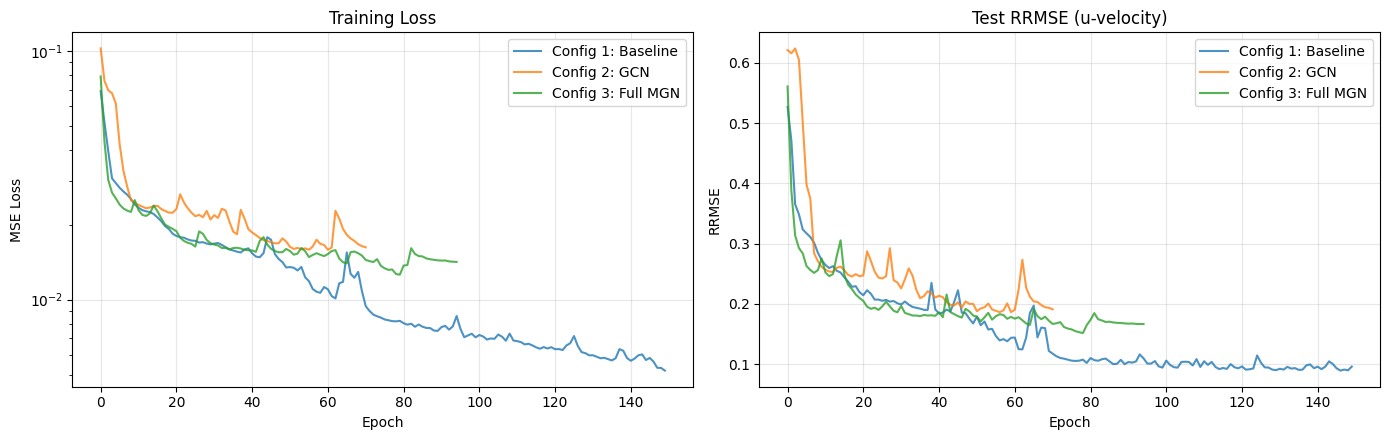

In [15]:
# Training loss comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Loss curves
axes[0].plot(losses_cfg1, label='Config 1: Baseline', alpha=0.8)
axes[0].plot(losses_cfg2, label='Config 2: GCN', alpha=0.8)
axes[0].plot(losses_cfg3, label='Config 3: Full MGN', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RRMSE for u-velocity over epochs
axes[1].plot(rrmses_cfg1[:, 0], label='Config 1: Baseline', alpha=0.8)
axes[1].plot(rrmses_cfg2[:, 0], label='Config 2: GCN', alpha=0.8)
axes[1].plot(rrmses_cfg3[:, 0], label='Config 3: Full MGN', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RRMSE')
axes[1].set_title('Test RRMSE (u-velocity)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Final RRMSE comparison table
print("Final Test RRMSE Comparison:")
print(f"{'Config':<30s} {'u':>10s} {'v':>10s} {'p':>10s}")
print("-" * 62)
for name, rrmses in [("1: Baseline", rrmses_cfg1), 
                      ("2: GCN Processor", rrmses_cfg2),
                      ("3: Full MeshGraphNet", rrmses_cfg3)]:
    final = rrmses[-1]
    print(f"{name:<30s} {final[0]:10.4f} {final[1]:10.4f} {final[2]:10.4f}")

Final Test RRMSE Comparison:
Config                                  u          v          p
--------------------------------------------------------------
1: Baseline                        0.0960     0.7451     0.3535
2: GCN Processor                   0.1911     1.0036     0.7570
3: Full MeshGraphNet               0.1666     1.0000     0.6913


## Predictions on test samples

Let me pick 2 test samples and plot ground truth vs predicted for the Full MeshGraphNet (Config 3) across all three fields (u, v, p). Even though it's not the best by RRMSE, it's the most architecturally interesting model to visualize.

## Analysis

Looking at the RRMSE table above, the Baseline (Config 1) achieves the best performance across all three fields. The Full MeshGraphNet (Config 3) comes second, and the GCN Processor (Config 2) performs worst. Both Configs 2 and 3 triggered early stopping before reaching 150 epochs, with the GCN stopping earliest around epoch 71.

This ranking makes sense when you consider what each architecture can and cannot do. The Baseline (Config 1) has only ~9.5k parameters and operates directly on the raw 8-dim features (coordinates, SDF, node type) without an encoder. These features are already physically meaningful, so the custom message passing layers can immediately use them. Its small size also prevents overfitting on our 48 training samples.

The GCN Processor (Config 2) performs worst despite having an encoder, because GCNConv ignores edge attributes entirely. It treats all neighbors equivalently regardless of their spatial relationship (relative position, distance), losing valuable geometric information. The v-velocity RRMSE stays near 1.0 for both Configs 2 and 3, meaning they essentially predict zero for v everywhere, while Config 1 does noticeably better.

The Full MeshGraphNet (Config 3) beats the GCN because its custom message passing does use edge features, but its 269k parameters make it overparameterized for this small dataset. The encoder adds a learned transformation that is not strictly necessary when the raw features are already informative.

The takeaway: model complexity must match dataset size, and geometric edge features matter. With limited data, simpler architectures that preserve raw physical features can outperform deeper, more parameterized networks. And among the larger models, using edge attributes (Config 3) clearly beats ignoring them (Config 2).

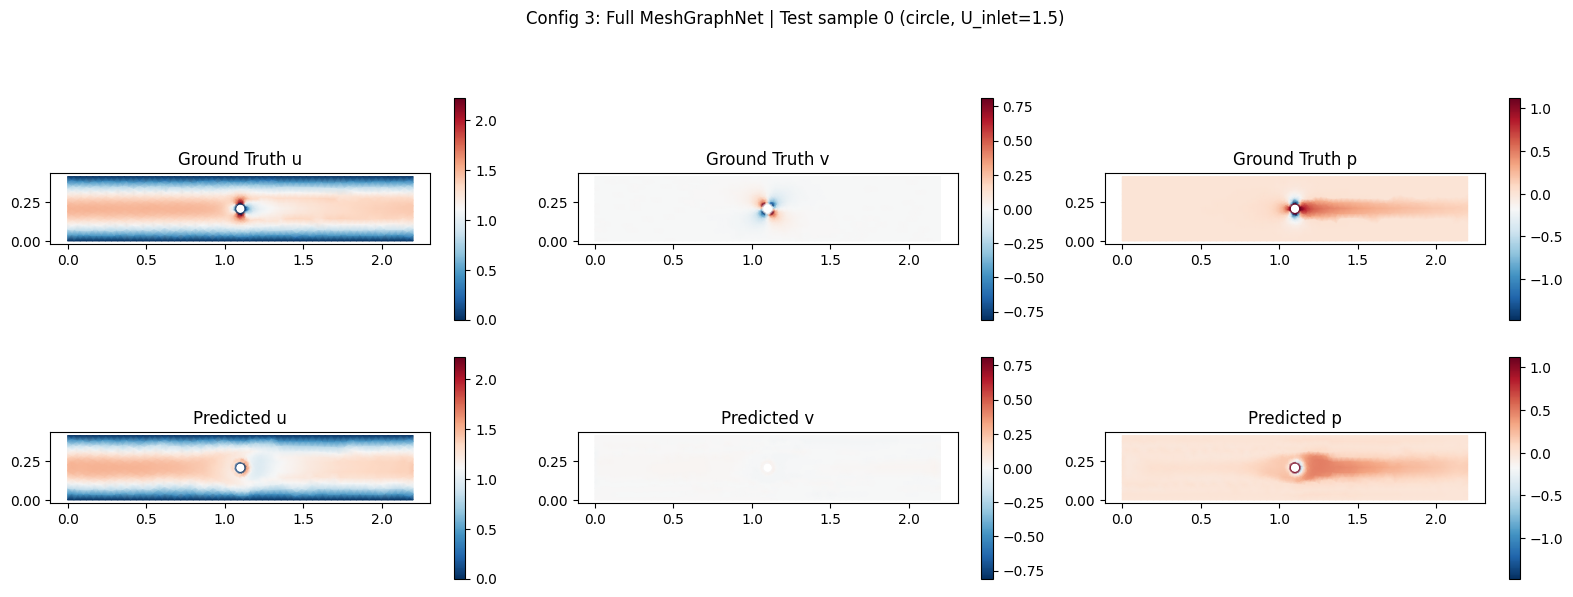

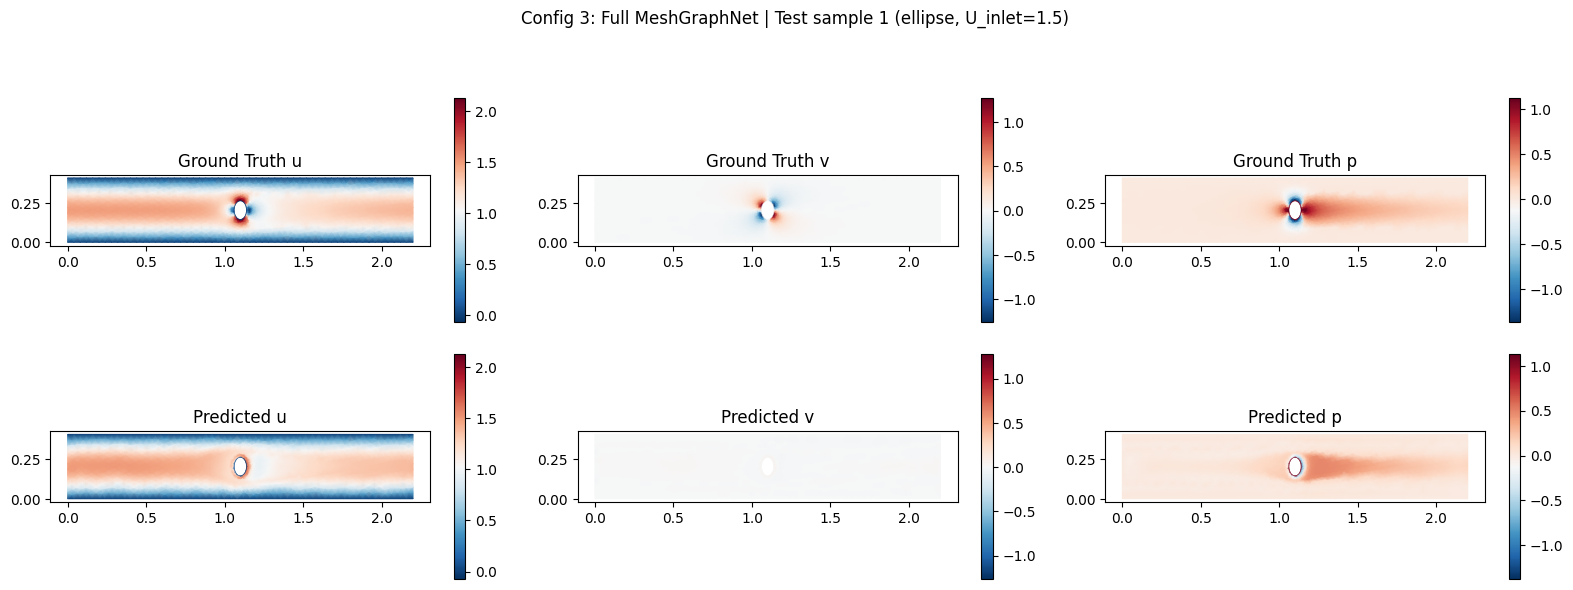

In [17]:
def plot_predictions(model, test_graphs, sample_indices, config_name, all_data_list, test_idx_list):
    """Plot ground truth vs predicted fields for selected test samples."""
    model.eval()
    
    for si in sample_indices:
        graph = test_graphs[si].to(device)
        with torch.no_grad():
            pred = model(graph).cpu().numpy()
        
        truth = graph.y.cpu().numpy()
        pos = graph.pos.cpu().numpy()
        x_pos, y_pos = pos[:, 0], pos[:, 1]
        
        # Rebuild triangulation from edge_index
        data_idx = test_idx_list[si]
        tris = all_data_list[data_idx]['triangles']
        tri = mtri.Triangulation(x_pos, y_pos, tris)
        
        fig, axes = plt.subplots(2, 3, figsize=(16, 6))
        fields = ['u', 'v', 'p']
        
        for col, field_name in enumerate(fields):
            gt = truth[:, col]
            pr = pred[:, col]
            vmin = min(gt.min(), pr.min())
            vmax = max(gt.max(), pr.max())
            
            tc0 = axes[0, col].tripcolor(tri, gt, cmap='RdBu_r', shading='gouraud', vmin=vmin, vmax=vmax)
            plt.colorbar(tc0, ax=axes[0, col], shrink=0.8)
            axes[0, col].set_title(f'Ground Truth {field_name}')
            axes[0, col].set_aspect('equal')
            
            tc1 = axes[1, col].tripcolor(tri, pr, cmap='RdBu_r', shading='gouraud', vmin=vmin, vmax=vmax)
            plt.colorbar(tc1, ax=axes[1, col], shrink=0.8)
            axes[1, col].set_title(f'Predicted {field_name}')
            axes[1, col].set_aspect('equal')
        
        sample_meta = all_data_list[data_idx]['meta']
        shape_str = sample_meta['shape']['type']
        u_in = sample_meta['U_inlet']
        plt.suptitle(f'{config_name} | Test sample {si} ({shape_str}, U_inlet={u_in})', y=1.02)
        plt.tight_layout()
        plt.show()

# Plot for the best model (Config 3: Full MeshGraphNet)
plot_predictions(model_cfg3, test_graphs, [0, 1], "Config 3: Full MeshGraphNet", all_data, test_idx)

# Q4. Bonus: Edge Subsampling

The idea here is to randomly remove edges during training (keeping all nodes) and see how sparse connectivity affects prediction quality. We train on subsampled graphs but evaluate on the full graphs. This tests whether the model can generalize from partial connectivity, and could also speed up training on large meshes.

In [18]:
def subsample_edges(graph, ratio):
    """Randomly subsample edges from a graph, keeping all nodes.
    ratio: fraction of edges to KEEP (e.g., 0.25 keeps 25% of edges)."""
    edge_index = graph.edge_index
    edge_attr = graph.edge_attr
    num_edges = edge_index.shape[1]
    
    # We need to keep edges in pairs (i->j and j->i) for undirected graphs
    # The first half are one direction, second half the reverse
    half = num_edges // 2
    n_keep = max(1, int(half * ratio))
    
    perm = torch.randperm(half)[:n_keep]
    # Keep both directions
    keep_idx = torch.cat([perm, perm + half])
    
    new_graph = Data(
        x=graph.x.clone(),
        edge_index=edge_index[:, keep_idx].clone(),
        edge_attr=edge_attr[keep_idx].clone(),
        y=graph.y.clone(),
        pos=graph.pos.clone(),
        node_type=graph.node_type.clone(),
        num_nodes=graph.num_nodes
    )
    return new_graph

# Test: subsample a graph
g = test_graphs[0]
for r in [0.05, 0.1, 0.25, 1.0]:
    gs = subsample_edges(g, r)
    print(f"  ratio={r:.2f}: {g.edge_index.shape[1]} -> {gs.edge_index.shape[1]} edges")

  ratio=0.05: 5398 -> 268 edges
  ratio=0.10: 5398 -> 538 edges
  ratio=0.25: 5398 -> 1348 edges
  ratio=1.00: 5398 -> 5398 edges


I'll use the Baseline architecture (Config 1) since it performed best in Q3. For each subsampling ratio, I create subsampled training graphs, train from scratch, then evaluate on the original full test graphs.

In [19]:
subsampling_ratios = [0.05, 0.1, 0.25, 1.0]
subsample_results = {}

# Ensure all graphs are on CPU for DataLoader (it handles .to(device) in train loop)
def ensure_cpu(graph_list):
    out = []
    for g in graph_list:
        out.append(Data(
            x=g.x.cpu(), edge_index=g.edge_index.cpu(), edge_attr=g.edge_attr.cpu(),
            y=g.y.cpu(), pos=g.pos.cpu(), node_type=g.node_type.cpu(), num_nodes=g.num_nodes
        ))
    return out

cpu_train = ensure_cpu(train_graphs)
cpu_test = ensure_cpu(test_graphs)
test_loader_cpu = PyGDataLoader(cpu_test, batch_size=4, shuffle=False)

for ratio in subsampling_ratios:
    print(f"\n{'='*60}")
    print(f"Edge subsampling ratio: {ratio}")
    print(f"{'='*60}")
    
    torch.manual_seed(0)
    np.random.seed(0)
    
    if ratio < 1.0:
        sub_train = [subsample_edges(g, ratio) for g in cpu_train]
    else:
        sub_train = cpu_train
    
    sub_loader = PyGDataLoader(sub_train, batch_size=4, shuffle=True)
    
    model_sub = MeshGraphNet(
        input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM, hidden_dim=64,
        num_mp_layers=10, edge_dim=EDGE_DIM, use_gcn=False, use_encoder=False
    ).to(device)
    
    losses_sub, rrmses_sub = train_model(
        model_sub, sub_loader, test_loader_cpu,
        epochs=EPOCHS, lr=LR, config_name=f"ratio={ratio}"
    )
    
    subsample_results[ratio] = {
        'losses': losses_sub,
        'rrmses': rrmses_sub,
        'model': model_sub
    }

print("\n\nEdge Subsampling Results (evaluated on full test graphs):")
print(f"{'Ratio':<10s} {'u':>10s} {'v':>10s} {'p':>10s}")
print("-" * 42)
for ratio in subsampling_ratios:
    final = subsample_results[ratio]['rrmses'][-1]
    print(f"{ratio:<10.2f} {final[0]:10.4f} {final[1]:10.4f} {final[2]:10.4f}")


Edge subsampling ratio: 0.05


  [ratio=0.05] epoch   1 | loss=1.1919e-01 | RRMSE u=0.6490 v=1.0532 p=0.9836


  [ratio=0.05] epoch  20 | loss=2.3858e-02 | RRMSE u=0.2684 v=1.0023 p=0.8959


  [ratio=0.05] epoch  40 | loss=1.6536e-02 | RRMSE u=0.1953 v=1.0003 p=0.7542


  [ratio=0.05] epoch  60 | loss=1.3493e-02 | RRMSE u=0.1731 v=0.9846 p=0.6241


...

  [ratio=1.0] epoch  80 | loss=9.7380e-03 | RRMSE u=0.1185 v=0.9559 p=0.3932


  [ratio=1.0] epoch 100 | loss=7.5549e-03 | RRMSE u=0.0996 v=0.9207 p=0.3235


  [ratio=1.0] epoch 120 | loss=6.7547e-03 | RRMSE u=0.0956 v=0.8757 p=0.3211


  [ratio=1.0] epoch 140 | loss=6.1002e-03 | RRMSE u=0.0977 v=0.8235 p=0.2899




Edge Subsampling Results (evaluated on full test graphs):
Ratio               u          v          p
------------------------------------------
0.05           0.0836     0.4251     0.2779
0.10           0.0772     0.4105     0.2713
0.25           0.0815     0.4089     0.2772
1.00           0.0931     0.7835     0.3103


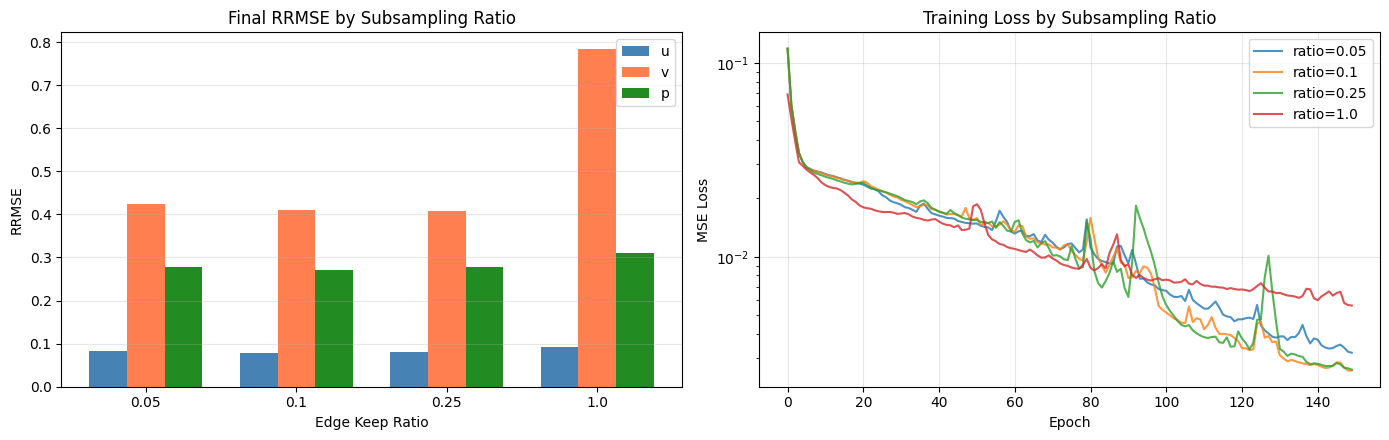

In [20]:
# Visualization: RRMSE vs subsampling ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Bar chart of final RRMSE per field per ratio
ratios_str = [str(r) for r in subsampling_ratios]
u_vals = [subsample_results[r]['rrmses'][-1][0] for r in subsampling_ratios]
v_vals = [subsample_results[r]['rrmses'][-1][1] for r in subsampling_ratios]
p_vals = [subsample_results[r]['rrmses'][-1][2] for r in subsampling_ratios]

x = np.arange(len(subsampling_ratios))
width = 0.25
axes[0].bar(x - width, u_vals, width, label='u', color='steelblue')
axes[0].bar(x, v_vals, width, label='v', color='coral')
axes[0].bar(x + width, p_vals, width, label='p', color='forestgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ratios_str)
axes[0].set_xlabel('Edge Keep Ratio')
axes[0].set_ylabel('RRMSE')
axes[0].set_title('Final RRMSE by Subsampling Ratio')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Training loss curves
for ratio in subsampling_ratios:
    axes[1].plot(subsample_results[ratio]['losses'], label=f'ratio={ratio}', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Training Loss by Subsampling Ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Edge Subsampling Discussion

The subsampling results in the table above are quite striking: all three subsampled ratios (5%, 10%, 25%) outperform the full graph on v-velocity by a wide margin. In fact, 25% edges achieves the best v-velocity RRMSE, while 10% edges achieves the best u-velocity. The full graph (100% edges) is not the best on any of the three fields.

This demonstrates that edge subsampling acts as a powerful regularizer. By randomly removing edges during training, the model cannot memorize specific local connectivity patterns and must learn more robust, generalizable features. The effect is conceptually similar to dropout, but applied at the graph structure level. Since the model is evaluated on the full graph at test time, it benefits from having learned to extract useful information from whatever edges happen to be available.

The v-velocity sees the largest improvement from subsampling. This is the hardest field to predict (small magnitude, directional), so it benefits most from the regularization effect that prevents overfitting.

For practical applications with large meshes (millions of nodes), training on only 10 to 25% of edges not only reduces memory and computational cost by 4 to 10x, but can actually produce better-generalizing models. The approach is essentially free since it just requires dropping random edges before batching.